In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
!pip install shap

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from category_encoders import TargetEncoder
from category_encoders import BinaryEncoder

import shap

In [ ]:
url = "https://raw.githubusercontent.com/vkoul/data/main/misc/hits_data_trivago.zip"

df = pd.read_csv(url, compression='zip',  sep=';', na_values= '\\N')

In [ ]:
df.head()

,row_num,locale,day_of_week,hour_of_day,agent_id,entry_page,path_id_set,traffic_type,session_durantion,hits
0,988681,L6,Monday,17,1,2111,31672;0,6,7037.0,NaN
1,988680,L2,Thursday,22,10,2113,31965;0,2,49.0,14.0
2,988679,L4,Saturday,21,2,2100,0;78464,1,1892.0,14.0
3,988678,L3,Saturday,19,8,2113,51462,6,0.0,1.0
4,988677,L2,Tuesday,6,10,2116,31931;0,1,2.0,3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988681 entries, 0 to 988680
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   row_num            988681 non-null  int64  
 1   locale             988681 non-null  object 
 2   day_of_week        988681 non-null  object 
 3   hour_of_day        988681 non-null  int64  
 4   agent_id           988681 non-null  int64  
 5   entry_page         988681 non-null  int64  
 6   path_id_set        983792 non-null  object 
 7   traffic_type       988681 non-null  int64  
 8   session_durantion  988013 non-null  float64
 9   hits               619235 non-null  float64
dtypes: float64(2), int64(5), object(3)
memory usage: 75.4+ MB


In [ ]:
df.isna().sum()

,0
row_num,0
locale,0
day_of_week,0
hour_of_day,0
agent_id,0
entry_page,0
path_id_set,4889
traffic_type,0
session_durantion,668
hits,369446


In [ ]:
df.isna().mean()

,0
row_num,0.000000
locale,0.000000
day_of_week,0.000000
hour_of_day,0.000000
agent_id,0.000000
entry_page,0.000000
path_id_set,0.004945
traffic_type,0.000000
session_durantion,0.000676
hits,0.373676


Most of the missing entries are in the hits column, which is the target column for the machine learning, so will need to be removed. The other rows with missing values make up less than 1% of the total data so it should be safe to remove them.

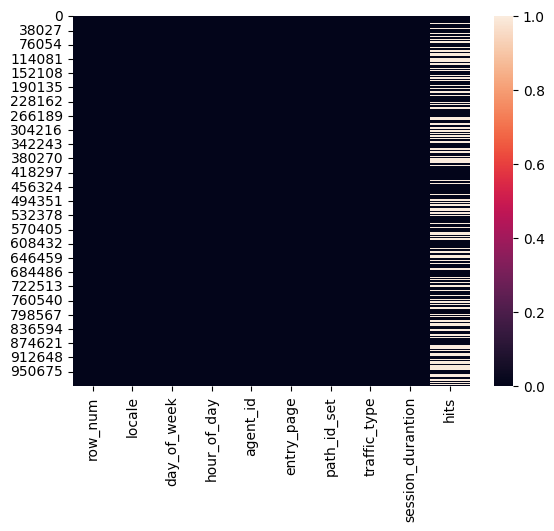

In [ ]:
sns.heatmap(df.isna());

Missing values appear to be randomly spaced, so it is not likely to be an error at a particular time, but just randomly not getting the data.

In [ ]:
df = df.copy()
df['session_durantion'] = pd.to_numeric(df['session_durantion'], errors='coerce')
df['hits'] = pd.to_numeric(df['hits'], errors='coerce')
df = df.dropna()

In [ ]:
df.isna().sum()

,0
row_num,0
locale,0
day_of_week,0
hour_of_day,0
agent_id,0
entry_page,0
path_id_set,0
traffic_type,0
session_durantion,0
hits,0


In [ ]:
df.describe().round(2)

,row_num,hour_of_day,agent_id,entry_page,traffic_type,session_durantion,hits
count,615668.00,615668.00,615668.00,615668.00,615668.00,615668.00,615668.00
mean,494104.46,13.20,7.43,2257.95,2.71,494.00,18.31
std,285455.62,6.76,3.98,785.31,1.87,1917.17,39.19
min,1.00,0.00,0.00,2100.00,1.00,0.00,1.00
25%,246839.75,8.00,2.00,2111.00,1.00,4.00,3.00
50%,493946.00,14.00,9.00,2113.00,2.00,59.00,7.00
75%,741299.25,19.00,10.00,2116.00,4.00,326.00,19.00
max,988680.00,23.00,15.00,8101.00,10.00,86219.00,4174.00


In [ ]:
df.nunique()

,0
row_num,615668
locale,6
day_of_week,7
hour_of_day,24
agent_id,15
entry_page,136
path_id_set,107045
traffic_type,7
session_durantion,9465
hits,812


In [ ]:
corr = df.corr(numeric_only = True).round(2)

<Axes: >

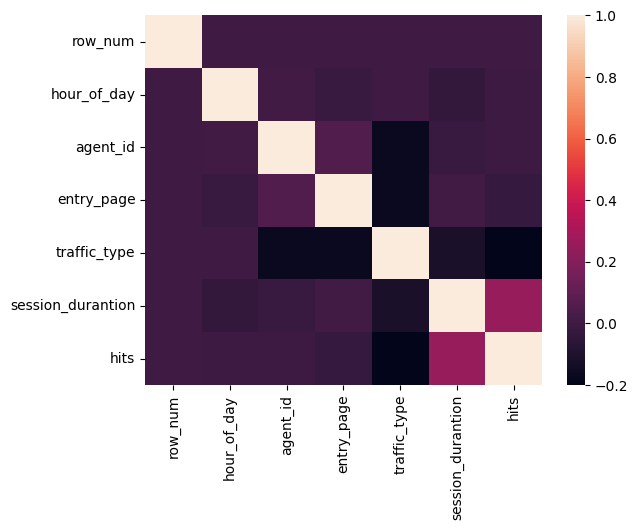

In [ ]:
sns.heatmap(corr)

Very low correlation between numeric columns in the data.

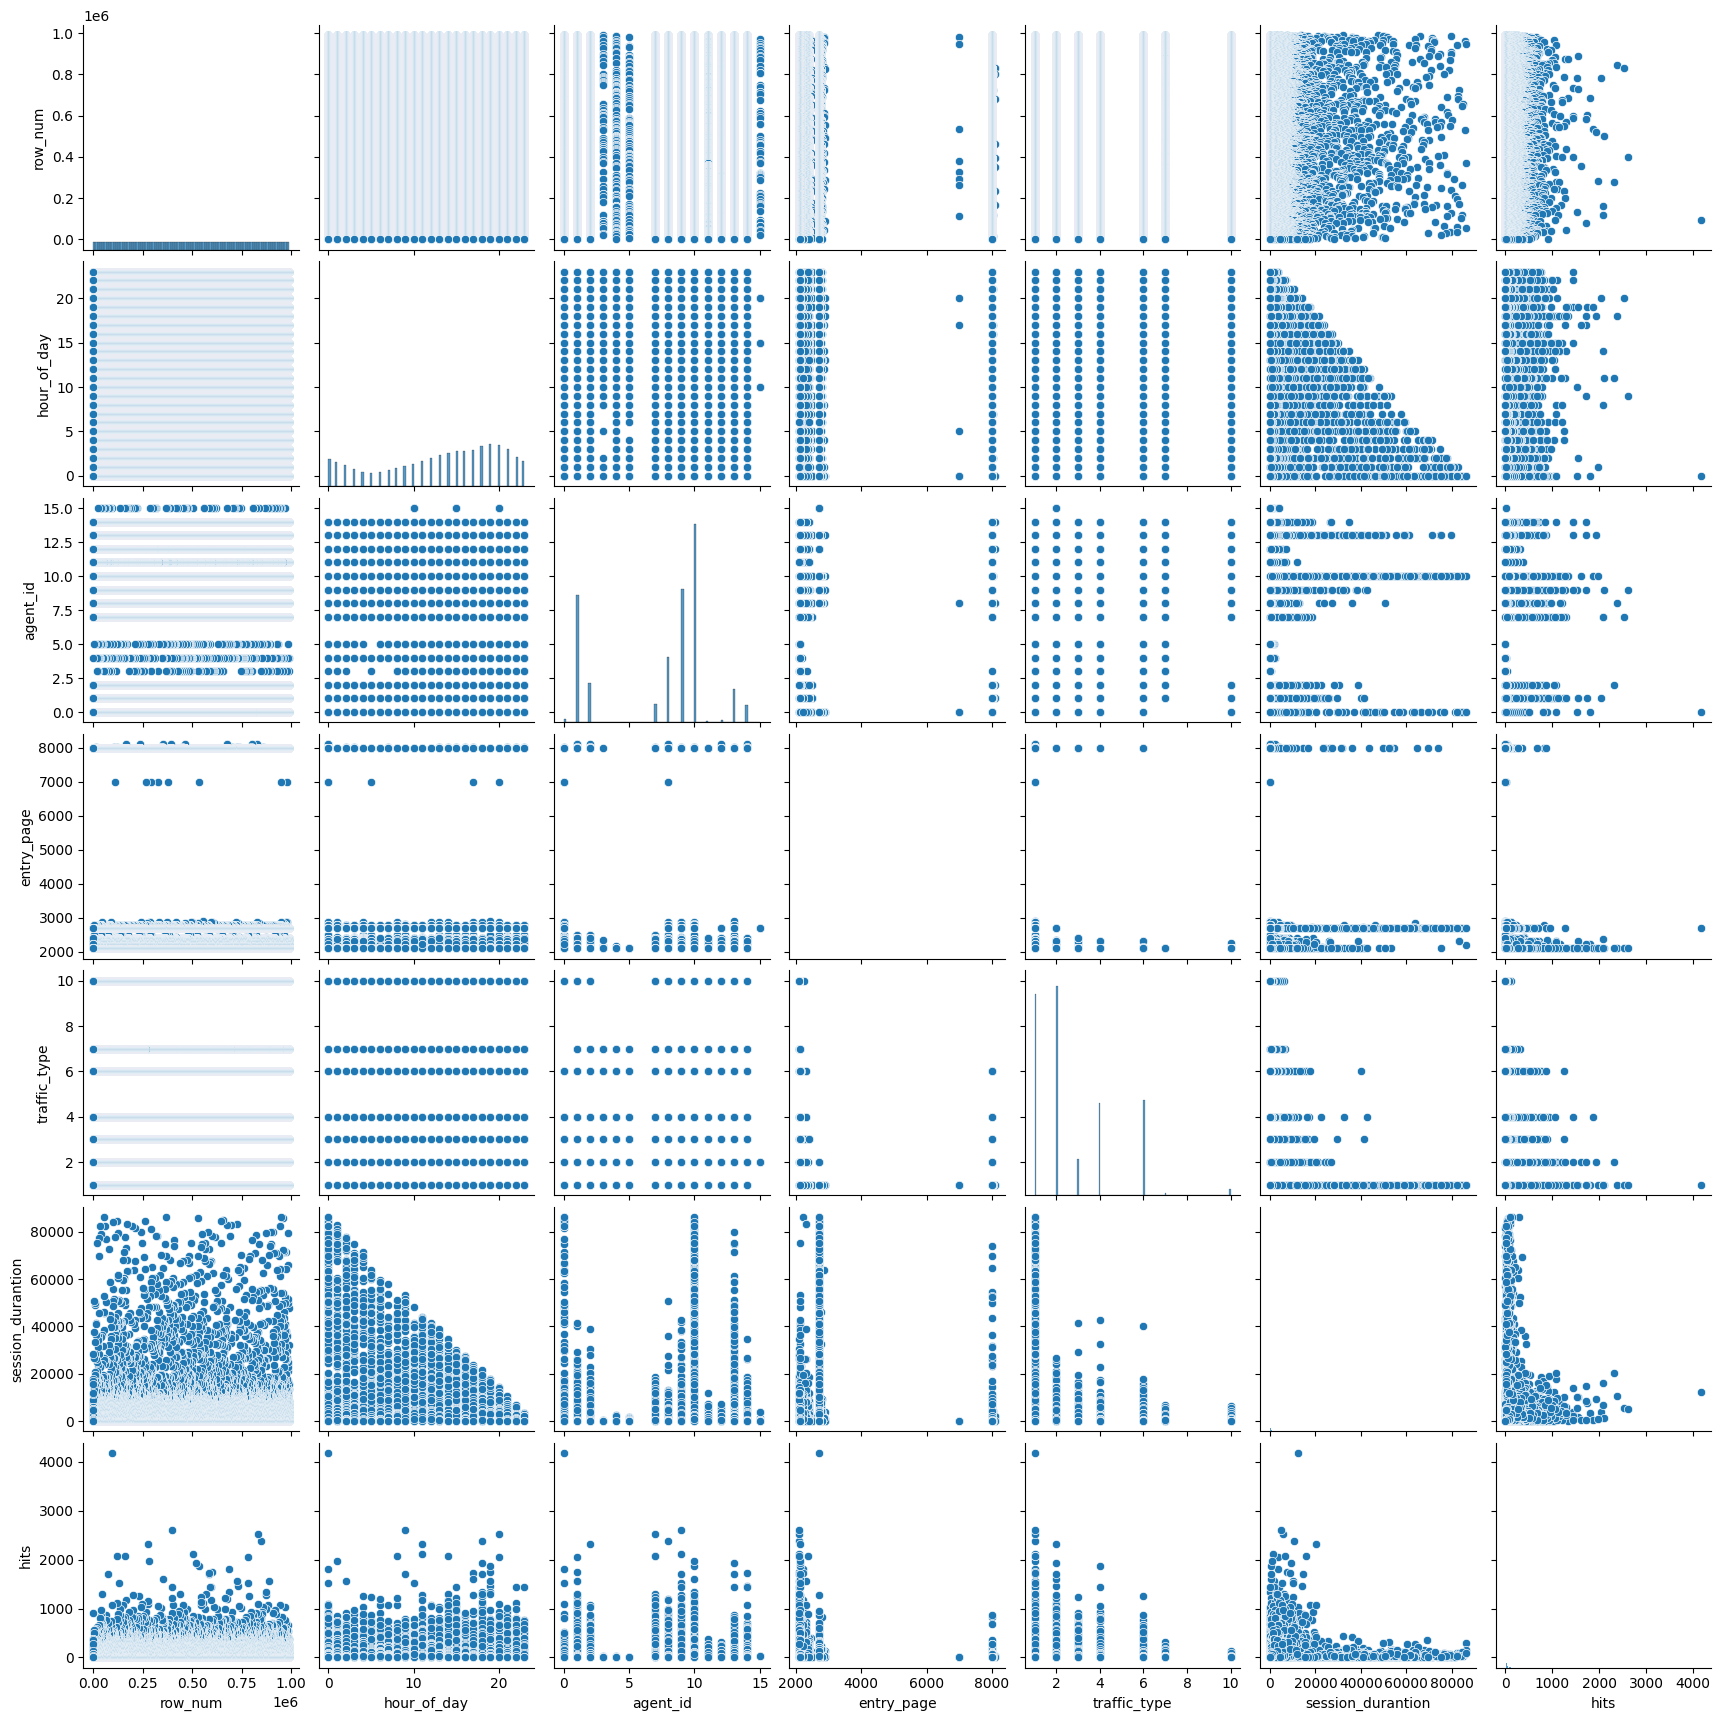

In [ ]:
sns.pairplot(df)

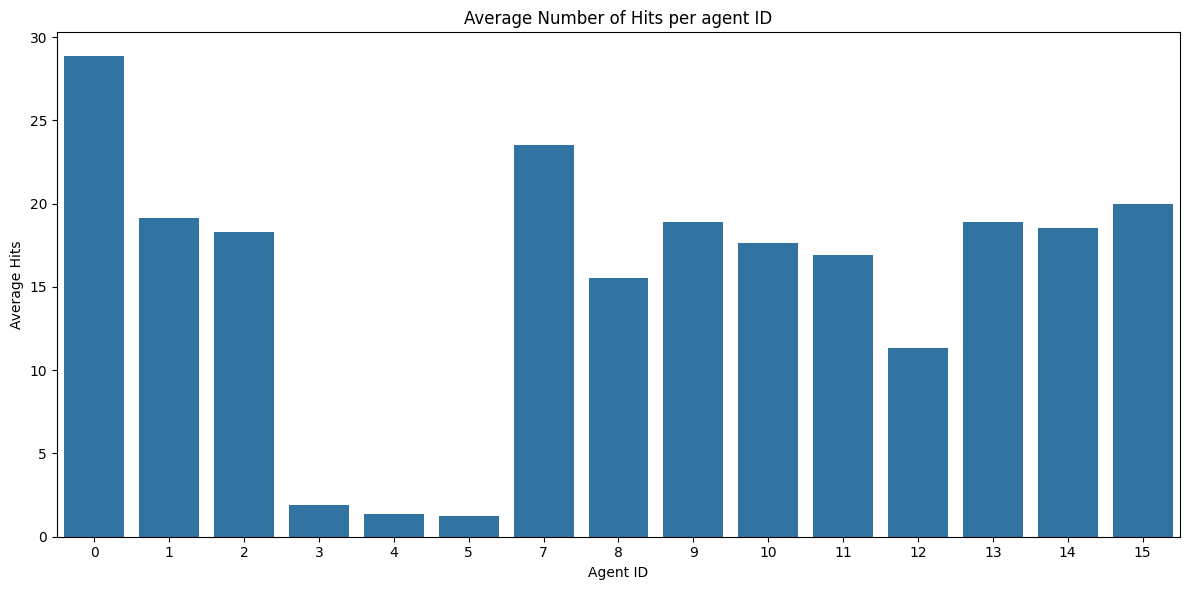

In [ ]:
average_hits_per_agent_id = df.groupby('agent_id')['hits'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=average_hits_per_agent_id, x='agent_id', y='hits')
plt.title('Average Number of Hits per agent ID')
plt.xlabel('Agent ID')
plt.ylabel('Average Hits')
plt.tight_layout()
plt.show()

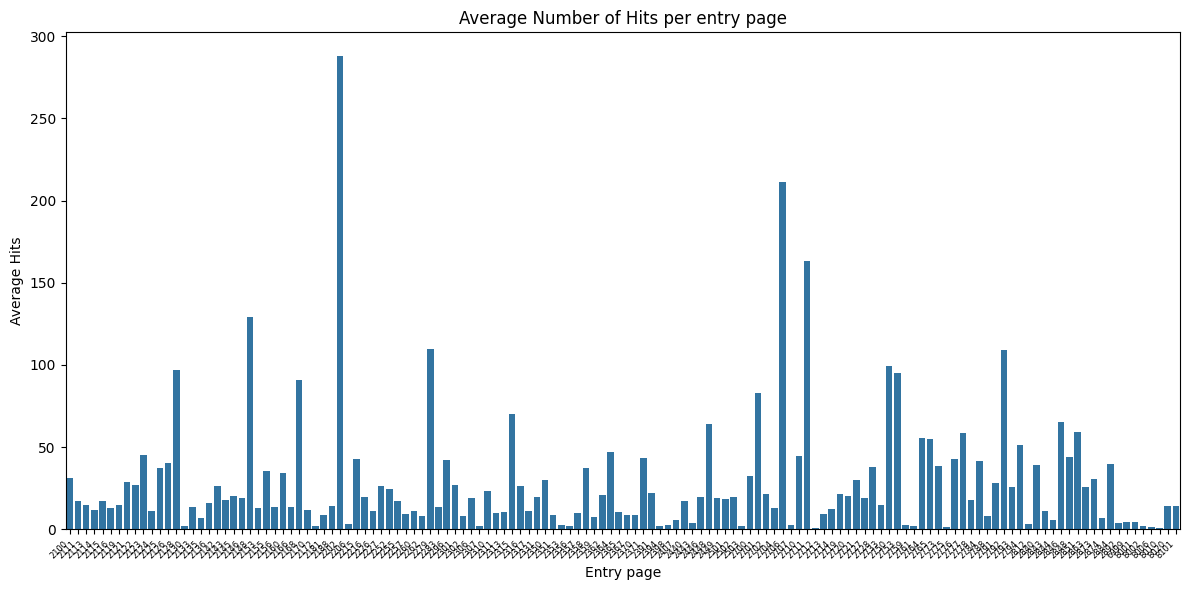

In [ ]:
average_hits_per_entry_page = df.groupby('entry_page')['hits'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=average_hits_per_entry_page, x='entry_page', y='hits')
plt.title('Average Number of Hits per entry page')
plt.xlabel('Entry page')
plt.ylabel('Average Hits')
plt.xticks(rotation=45, ha='right', fontsize=6)
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.show()

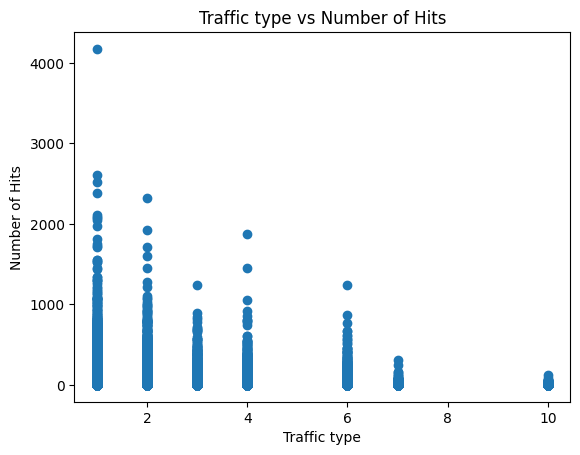

In [ ]:
plt.plot(df['traffic_type'], df['hits'], 'o')

plt.title('Traffic type vs Number of Hits')
plt.xlabel('Traffic type')
plt.ylabel('Number of Hits')
plt.show()

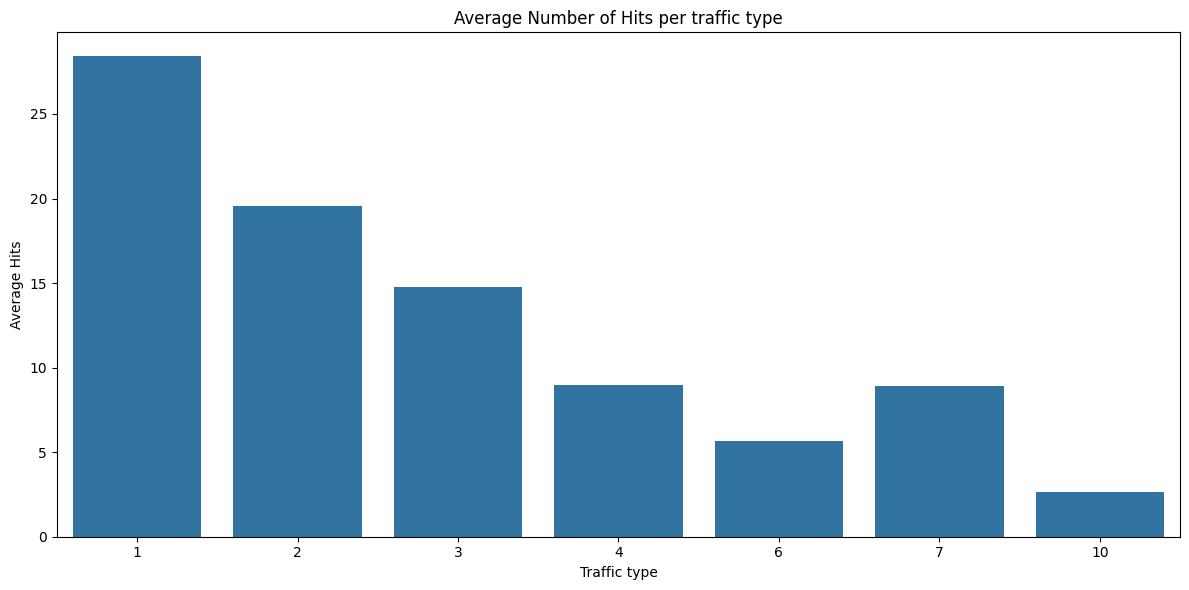

In [ ]:
average_hits_per_traffic_type = df.groupby('traffic_type')['hits'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=average_hits_per_traffic_type, x='traffic_type', y='hits')
plt.title('Average Number of Hits per traffic type')
plt.xlabel('Traffic type')
plt.ylabel('Average Hits')
plt.tight_layout()
plt.show()

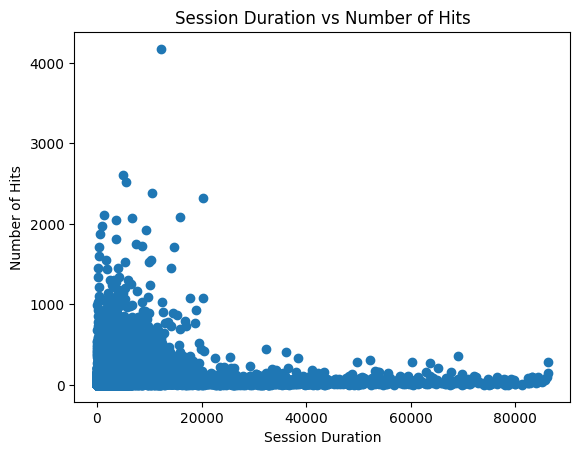

In [ ]:
plt.plot(df['session_durantion'], df['hits'], 'o')

plt.title('Session Duration vs Number of Hits')
plt.xlabel('Session Duration')
plt.ylabel('Number of Hits')
plt.show()

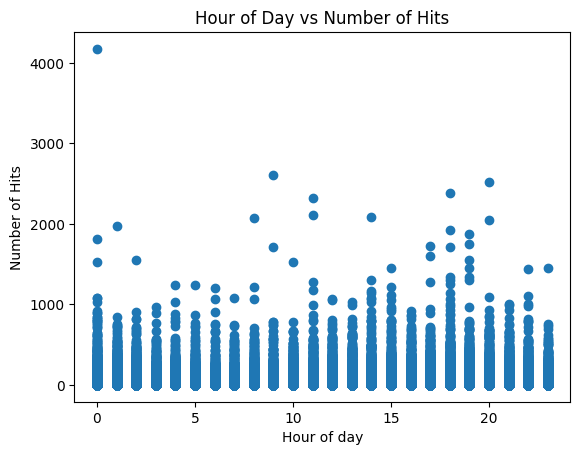

In [ ]:
plt.plot(df['hour_of_day'], df['hits'], 'o')

plt.title('Hour of Day vs Number of Hits')
plt.xlabel('Hour of day')
plt.ylabel('Number of Hits')
plt.show()

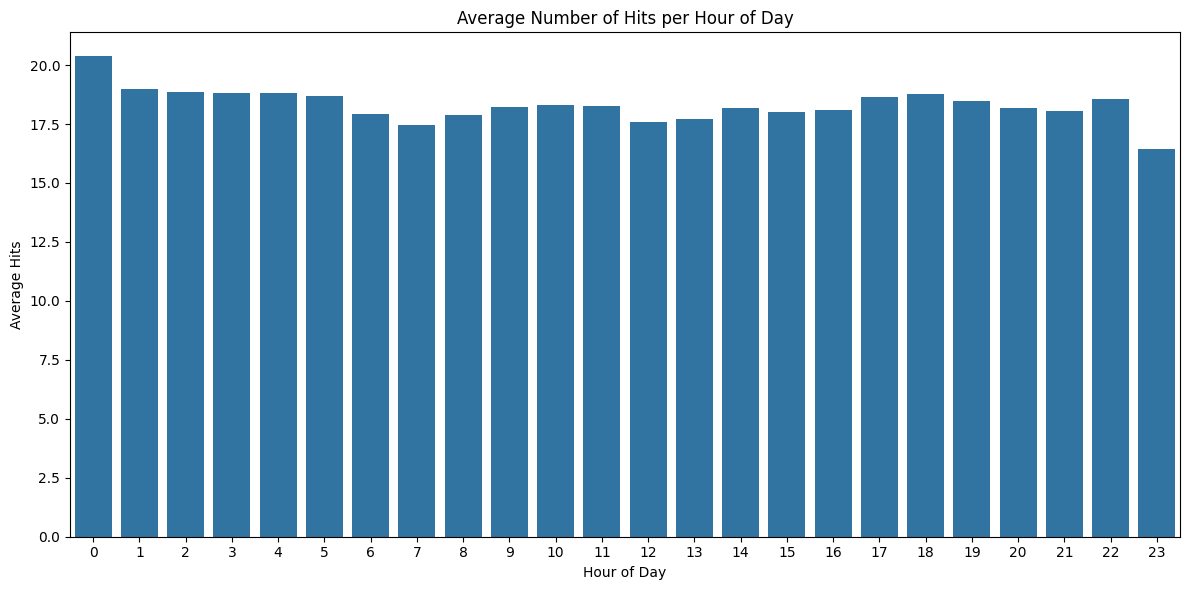

In [ ]:
average_hits_per_hour = df.groupby('hour_of_day')['hits'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=average_hits_per_hour, x='hour_of_day', y='hits')
plt.title('Average Number of Hits per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Hits')
plt.tight_layout()
plt.show()

In [ ]:
print(max(df['hits']))

4174.0


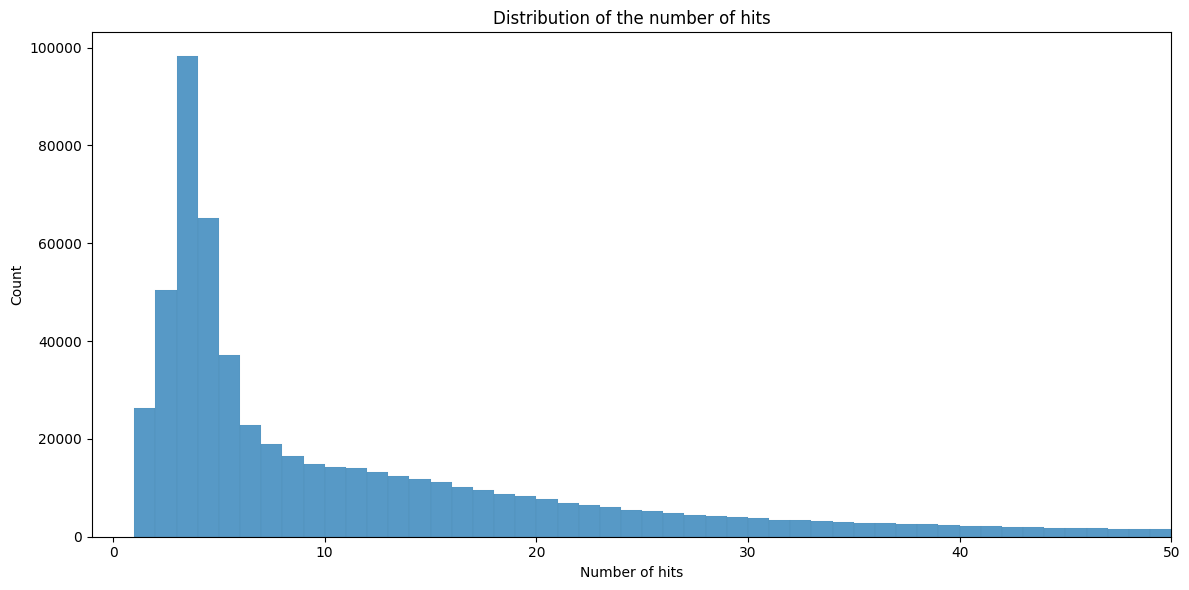

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='hits', bins=range(int(df['hits'].min()), int(df['hits'].max()) + 2), kde=False)
plt.title('Distribution of the number of hits')
plt.xlabel('Number of hits')
plt.ylabel('Count')
plt.xlim(-1, 50)
plt.tight_layout()
plt.show()

Most common result is 3. The results continue at low frequencies, with highest result at 4174.

In [ ]:
print(max(df['session_durantion']))

86219.0


Text(0.5, 1.0, 'Hour of day vs Session Duration')

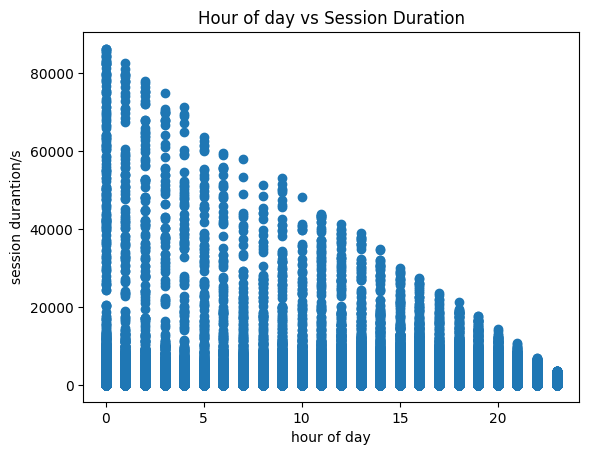

In [ ]:
plt.plot(df['hour_of_day'], df['session_durantion'], 'o')
plt.xlabel('hour of day')
plt.ylabel('session durantion/s')
plt.title('Hour of day vs Session Duration')

There appears to be a limit on the session duration that decreases as the hour of the day increases. The limit if the hour of day is midnight is just under 24 hours and appears to decrease linearly. This could be caused by the sessions in the data all having to be contained within the day that the data was collected on. This means sessions going across midnight may not be included which could affect the results.

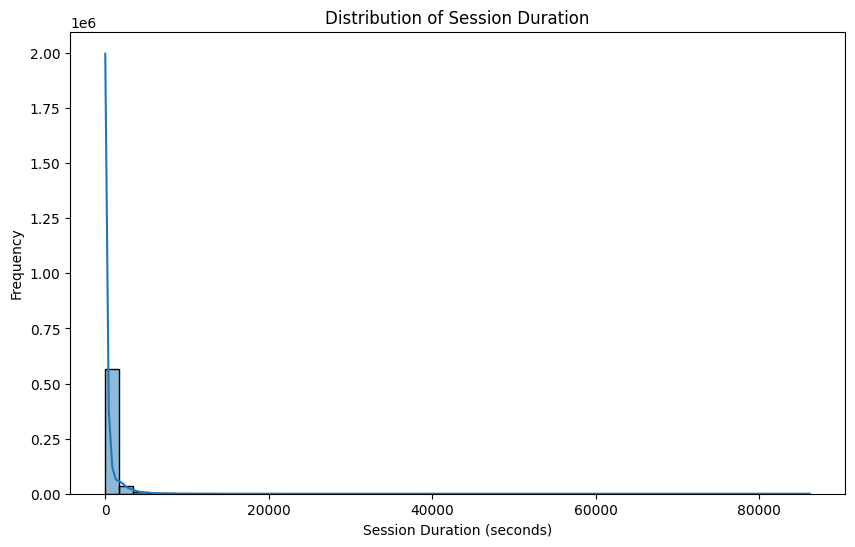

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['session_durantion'], bins=50, kde=True)
plt.title('Distribution of Session Duration')
plt.xlabel('Session Duration (seconds)')
plt.ylabel('Frequency')
plt.show()

Almost all the values for session duration are small, so the amount that are affected by the above issue will be small.

# Pre-processing

Start with time, duration, traffic type, day of week and platform.

In [ ]:
X = df.drop(columns = ["row_num", "hits", "path_id_set", "entry_page", "agent_id"])
y = df["hits"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(430967, 5)
(184701, 5)
(430967,)
(184701,)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

In [ ]:
ohe = OneHotEncoder(drop = "first",  sparse_output= False) # never put it false for heavy files
sd = StandardScaler()

In [ ]:
numerical_cols = ["hour_of_day", "session_durantion"]

categorical_cols = ["locale", "day_of_week", "traffic_type"]

In [ ]:
ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ], remainder = "passthrough")

# set output to pandas
ct.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('standardize', StandardScaler(),
                                 ['hour_of_day', 'session_durantion']),
                                ('encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['locale', 'day_of_week', 'traffic_type'])])

In [ ]:
X_train = ct.fit_transform(X_train) # never use this on test data

X_test = ct.transform(X_test) # test data only has transform, never fit

In [ ]:
ct

ColumnTransformer(remainder='passthrough',
                  transformers=[('standardize', StandardScaler(),
                                 ['hour_of_day', 'session_durantion']),
                                ('encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['locale', 'day_of_week', 'traffic_type'])])

In [ ]:
X_train

,standardize__hour_of_day,standardize__session_durantion,encoder__locale_L2,encoder__locale_L3,encoder__locale_L4,encoder__locale_L5,encoder__locale_L6,encoder__day_of_week_Monday,encoder__day_of_week_Saturday,encoder__day_of_week_Sunday,encoder__day_of_week_Thursday,encoder__day_of_week_Tuesday,encoder__day_of_week_Wednesday,encoder__traffic_type_2,encoder__traffic_type_3,encoder__traffic_type_4,encoder__traffic_type_6,encoder__traffic_type_7,encoder__traffic_type_10
924338,-0.768463,1.180287,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
264018,0.562196,-0.209973,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
909992,-0.620612,-0.259378,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
321658,-1.951270,-0.158442,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
329463,1.153599,-0.157911,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
896372,1.005748,-0.192973,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
135652,1.153599,-0.072381,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
703370,-1.212015,-0.132943,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
326690,0.266494,-0.260972,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#Model Building

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import root_mean_squared_error

dummy = DummyRegressor()

dummy.fit(X_train, y_train)

DummyRegressor()

In [ ]:
# model score- how well the model explains the reality
print(dummy.score(X_train, y_train))


# model rmse
train_pred = dummy.predict(X_train)
test_pred = dummy.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)


0.0


In [ ]:
print(train_rmse)
print(test_rmse)

38.96408473317513
39.71571338759318


In [ ]:
y_train.mean()
y_test.mean()

np.float64(18.30995500836487)

#Linear regression

In [ ]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

lm.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(lm.score(X_train, y_train))


# model rmse
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

0.10039778419787537


In [ ]:
print(train_rmse)
print(test_rmse)

36.95640666049082
37.86180744538871


Slight improvement over dummy regressor.

#Lasso

In [ ]:
from sklearn.linear_model import Lasso

In [ ]:
lasso = Lasso()

lasso.fit(X_train, y_train)

Lasso()

In [ ]:
train_pred = lasso.predict(X_train)
test_pred = lasso.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

37.41508515500512
38.29838786639088


In [ ]:
#lasso_alphas = np.linspace(0.001, 10.0, num=50)
lasso_alphas = [0.0001, 0.001, 0.01]

Optimal Alpha Value for lasso is: 0.0001


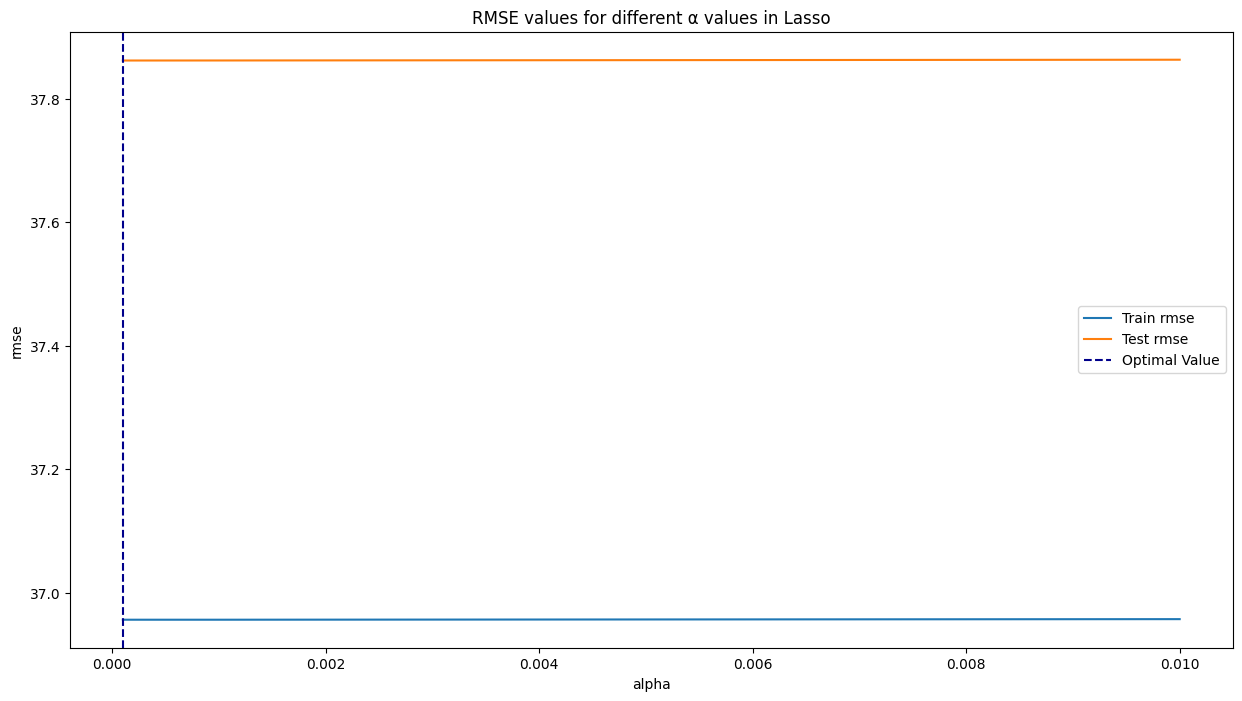

In [ ]:
train_rmse = []
test_rmse = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)

    train_preds = lasso.predict(X_train)
    train_rmse.append(root_mean_squared_error(y_train, train_preds))

    test_preds = lasso.predict(X_test)
    test_rmse.append(root_mean_squared_error(y_test, test_preds))

plt.figure(figsize = (15,8))
plt.plot(lasso_alphas, train_rmse, label='Train rmse')
plt.plot(lasso_alphas, test_rmse, label='Test rmse')
plt.title("RMSE values for different α values in Lasso")
plt.xlabel('alpha')
plt.ylabel('rmse')
plt.legend()

# np.argmin() returns the index of the minimum value in a list
optimal_alpha = lasso_alphas[np.argmin(test_rmse)]

# Add a vertical line where the test rmse is minimized
plt.axvline(optimal_alpha, color='darkblue', linestyle='--', label = "Optimal Value")
plt.legend();

print(f'Optimal Alpha Value for lasso is: {float(optimal_alpha)}')

In [ ]:
print(train_rmse)
print(test_rmse)

[36.95640676861992, 36.95641720957065, 36.95735246173673]
[37.86181420312197, 37.86187803257327, 37.863103566069675]


Has a train rmse of 36.9 and test rmse of 37.8, which is same as linear, so is probably keeping all the terms.

#Ridge

In [ ]:
from sklearn.linear_model import Ridge

In [ ]:
ridge_alphas = np.linspace(0.0001, 10, num=20)


Optimal Alpha Value for Ridge is: 0.0001


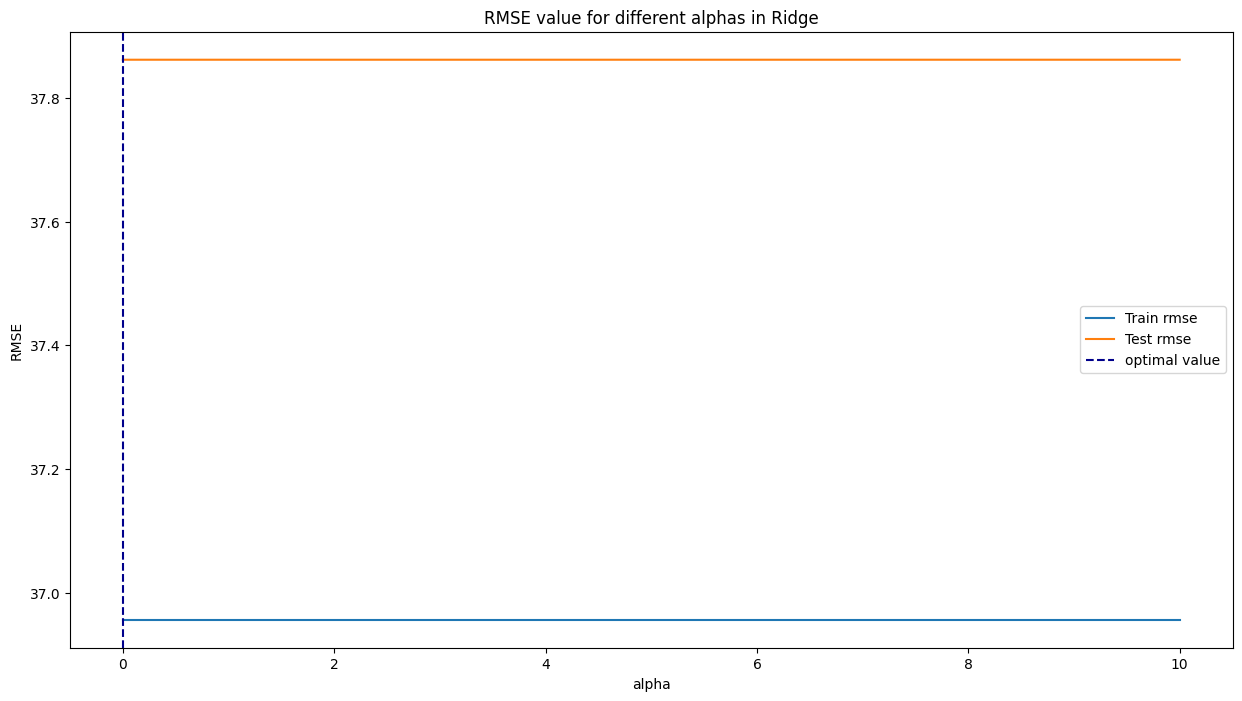

In [ ]:
ridge_train_rmse = []
ridge_test_rmse = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)

    train_preds = ridge.predict(X_train)
    ridge_train_rmse.append(root_mean_squared_error(y_train, train_preds))

    test_preds = ridge.predict(X_test)
    ridge_test_rmse.append(root_mean_squared_error(y_test, test_preds))


plt.figure(figsize = (15,8))
plt.plot(ridge_alphas, ridge_train_rmse, label='Train rmse')
plt.plot(ridge_alphas, ridge_test_rmse, label='Test rmse')

plt.title("RMSE value for different alphas in Ridge")
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()

# np.argmin() returns the index of the minimum value in a list
optimal_alpha = ridge_alphas[np.argmin(test_rmse)]

# Add a vertical line where the test rmse is minimized
plt.axvline(optimal_alpha, color='darkblue', linestyle='--', label = "optimal value")
plt.legend();


print(f'Optimal Alpha Value for Ridge is: {float(optimal_alpha)}')

In [ ]:
print(ridge_train_rmse)
print(ridge_test_rmse)

[36.95640666049082, 36.95640666412942, 36.95640667503414, 36.95640669319257, 36.95640671859232, 36.956406751221, 36.95640679106631, 36.95640683811589, 36.9564068923575, 36.95640695377883, 36.95640702236769, 36.95640709811183, 36.956407180999086, 36.956407271017305, 36.95640736815434, 36.95640747239809, 36.956407583736485, 36.956407702157456, 36.95640782764898, 36.95640796019905]
[37.86180744543297, 37.861807681930536, 37.861807925506234, 37.8618081761479, 37.86180843384344, 37.86180869858076, 37.86180897034779, 37.86180924913248, 37.86180953492283, 37.861809827706836, 37.861810127472545, 37.86181043420801, 37.86181074790132, 37.8618110685406, 37.861811396113964, 37.8618117306096, 37.86181207201568, 37.86181242032042, 37.86181277551205, 37.86181313757884]


Train rmse of 36.9 and test rmse of 37.8 again, so same thing as before happening.

#Random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor



In [ ]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
print(rf.score(X_train, y_train))


# model rmse
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

0.8707241505902268


In [ ]:
print(train_rmse)
print(test_rmse)

14.009517533777366
36.994690862774846


Train score a lot better, but test score only slightly better. Need to try hyperparameter tuning.

In [ ]:
depths = [4,5,6,7,8,9,10]

[33.815500079234425, 33.67003275535059, 33.47257700327074, 33.05136112814031, 32.81069193688881, 32.35857671234728, 31.817120283013836]
[34.8037621648697, 34.70227845853514, 34.6202361213174, 34.59373975381208, 34.526129222676964, 34.548466485965434, 34.555021689503214]


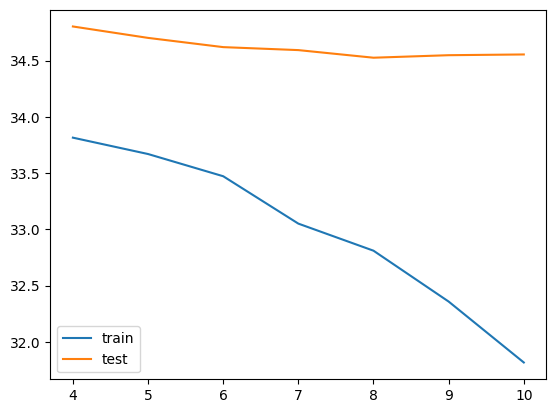

In [ ]:
test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

In [ ]:
best_rf = RandomForestRegressor(max_depth=8)
best_rf.fit(X_train, y_train)

feature_importances = rf.feature_importances_
feature_names = ct.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 most common factors in the Decision Tree Model:")
print(importance_df.head(10))

Top 10 most common factors in the Decision Tree Model:
                           Feature  Importance
1   standardize__session_durantion    0.864042
0         standardize__hour_of_day    0.033091
16         encoder__traffic_type_6    0.028096
7      encoder__day_of_week_Monday    0.008731
13         encoder__traffic_type_2    0.008635
15         encoder__traffic_type_4    0.007591
14         encoder__traffic_type_3    0.006722
9      encoder__day_of_week_Sunday    0.006141
3               encoder__locale_L3    0.005567
2               encoder__locale_L2    0.004849


The best test rmse with random forest is at a max depth of 8, with a test rmse of 34.5 and a train rmse of 32.8.

#k-nearest neighbours

In [ ]:
#from sklearn.neighbors import KNeighborsRegressor

In [ ]:
#knn = KNeighborsRegressor(n_neighbors=2)

#knn.fit(X_train, y_train)

In [ ]:
#train_pred = knn.predict(X_train)
#test_pred = knn.predict(X_test)

#train_rmse = root_mean_squared_error(y_train, train_pred)
#test_rmse = root_mean_squared_error(y_test, test_pred)

In [ ]:
#print(train_rmse)
#print(test_rmse)

Takes a long time to calculate predictions - about 30 mins for each try, so hyperparameter tuning would take several hours.

#Pre-process with additional categories

In [ ]:
X = df.drop(columns = ["row_num", "hits", "path_id_set", "entry_page"])
y = df["hits"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(430967, 6)
(184701, 6)
(430967,)
(184701,)


In [ ]:
ohe = OneHotEncoder(drop = "first",  sparse_output= False) # never put it false for heavy files
sd = StandardScaler()

In [ ]:
numerical_cols = ["session_durantion"]

categorical_cols = ["hour_of_day", "locale", "day_of_week", "traffic_type", "agent_id"]
#large_cat_cols - []

Trying with hour of day as categorical and with agent id

In [ ]:
ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ], remainder = "passthrough")

# set output to pandas
ct.set_output(transform="pandas")

ColumnTransformer(remainder='passthrough',
                  transformers=[('standardize', StandardScaler(),
                                 ['session_durantion']),
                                ('encoder',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['hour_of_day', 'locale', 'day_of_week',
                                  'traffic_type', 'agent_id'])])

In [ ]:
X_train = ct.fit_transform(X_train) # never use this on test data

X_test = ct.transform(X_test) # test data only has transform, never fit

#Linear

In [ ]:
lm = LinearRegression()

lm.fit(X_train, y_train)

print(lm.score(X_train, y_train))


# model rmse
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

0.10324979845028004
36.89777859851937
37.807255601821076


Slight improvement on previous linear model.

#Lasso

In [ ]:
lasso = Lasso()

lasso.fit(X_train, y_train)

train_pred = lasso.predict(X_train)
test_pred = lasso.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

37.41508515500512
38.29838786639088


Without hyperparameter tuning, gives worse result than linear model.

Optimal Alpha Value for lasso is: 0.001
36.898139106710246
37.80746776404368


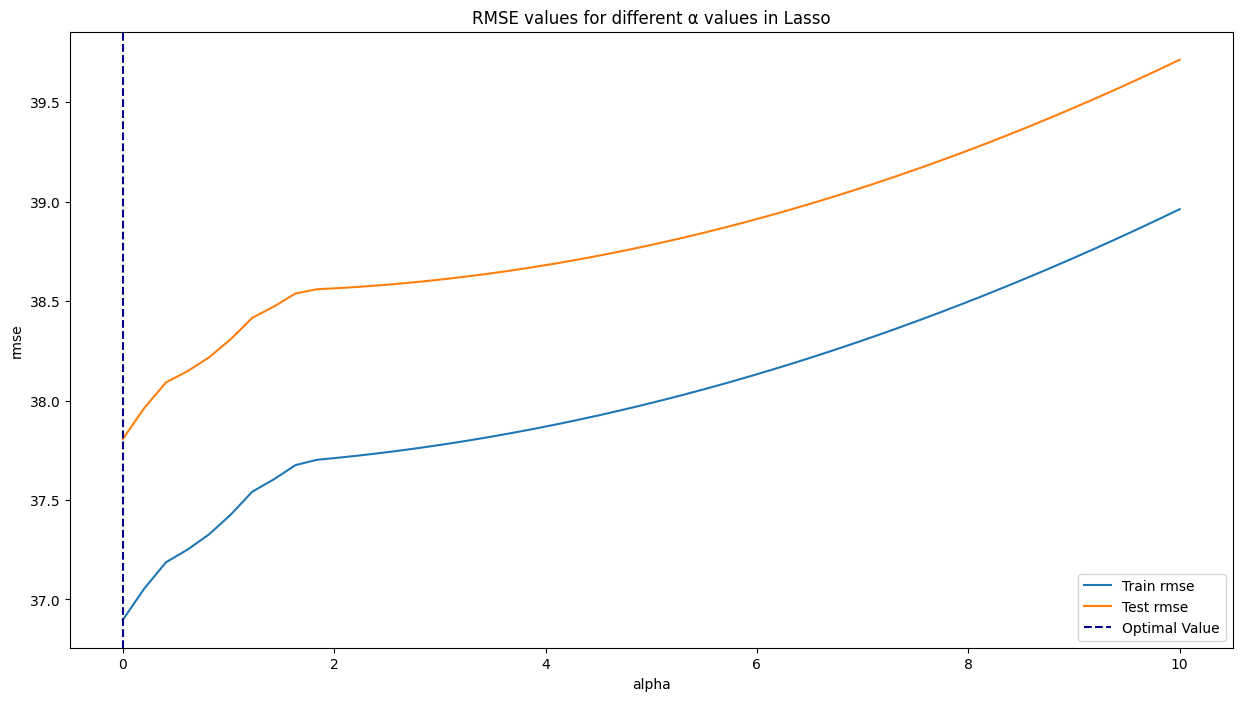

In [ ]:
lasso_alphas = np.linspace(0.001, 10.0, num=50)

train_rmse = []
test_rmse = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)

    train_preds = lasso.predict(X_train)
    train_rmse.append(root_mean_squared_error(y_train, train_preds))

    test_preds = lasso.predict(X_test)
    test_rmse.append(root_mean_squared_error(y_test, test_preds))

plt.figure(figsize = (15,8))
plt.plot(lasso_alphas, train_rmse, label='Train rmse')
plt.plot(lasso_alphas, test_rmse, label='Test rmse')
plt.title("RMSE values for different α values in Lasso")
plt.xlabel('alpha')
plt.ylabel('rmse')
plt.legend()

# np.argmin() returns the index of the minimum value in a list
optimal_alpha = lasso_alphas[np.argmin(test_rmse)]

# Add a vertical line where the test rmse is minimized
plt.axvline(optimal_alpha, color='darkblue', linestyle='--', label = "Optimal Value")
plt.legend();

print(f'Optimal Alpha Value for lasso is: {float(optimal_alpha)}')
print(min(train_rmse))
print(min(test_rmse))

Best result almost certainly lower.

Optimal Alpha Value for lasso is: 1e-05
36.89777865746066
37.80725396877123


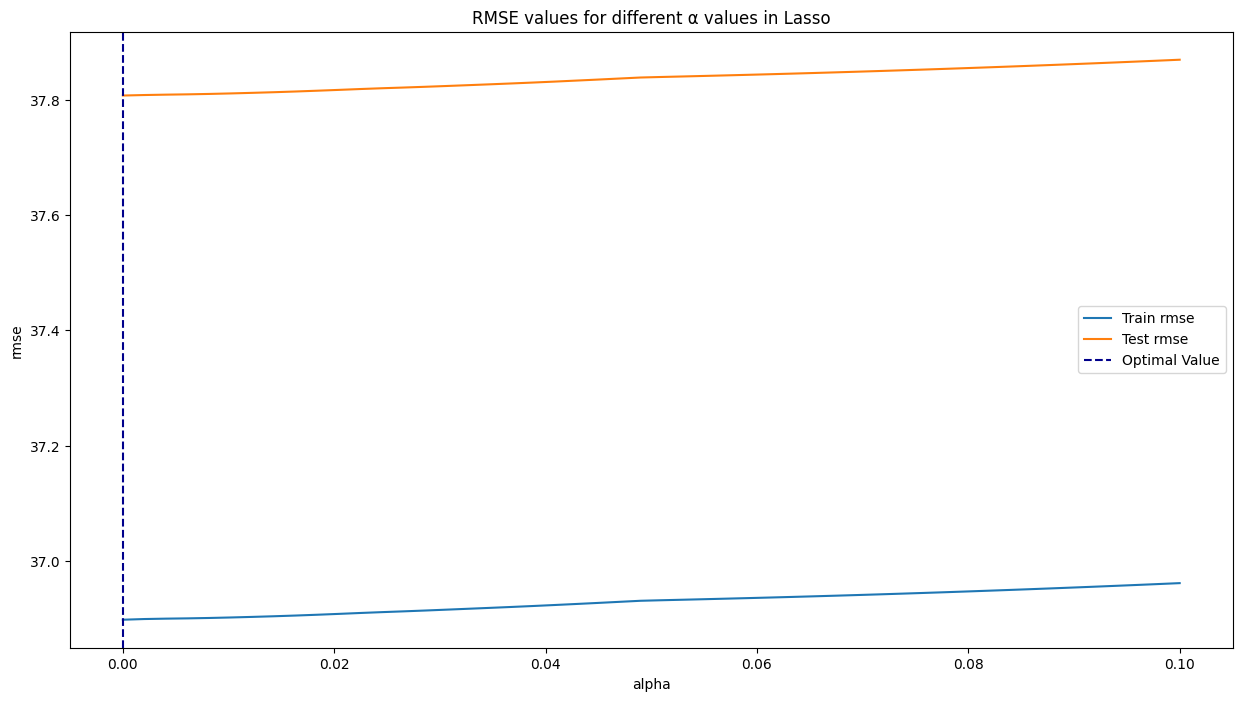

In [ ]:
lasso_alphas = np.linspace(0.00001, 0.1, num=50)

train_rmse = []
test_rmse = []

for alpha in lasso_alphas:
    lasso = Lasso(alpha = alpha)
    lasso.fit(X_train, y_train)

    train_preds = lasso.predict(X_train)
    train_rmse.append(root_mean_squared_error(y_train, train_preds))

    test_preds = lasso.predict(X_test)
    test_rmse.append(root_mean_squared_error(y_test, test_preds))

plt.figure(figsize = (15,8))
plt.plot(lasso_alphas, train_rmse, label='Train rmse')
plt.plot(lasso_alphas, test_rmse, label='Test rmse')
plt.title("RMSE values for different α values in Lasso")
plt.xlabel('alpha')
plt.ylabel('rmse')
plt.legend()

# np.argmin() returns the index of the minimum value in a list
optimal_alpha = lasso_alphas[np.argmin(test_rmse)]

# Add a vertical line where the test rmse is minimized
plt.axvline(optimal_alpha, color='darkblue', linestyle='--', label = "Optimal Value")
plt.legend();

print(f'Optimal Alpha Value for lasso is: {float(optimal_alpha)}')
print(min(train_rmse))
print(min(test_rmse))

Same result as linear model.

#Ridge

Optimal Alpha Value for Ridge is: 0.0001
36.89777859851938
37.807230096580504


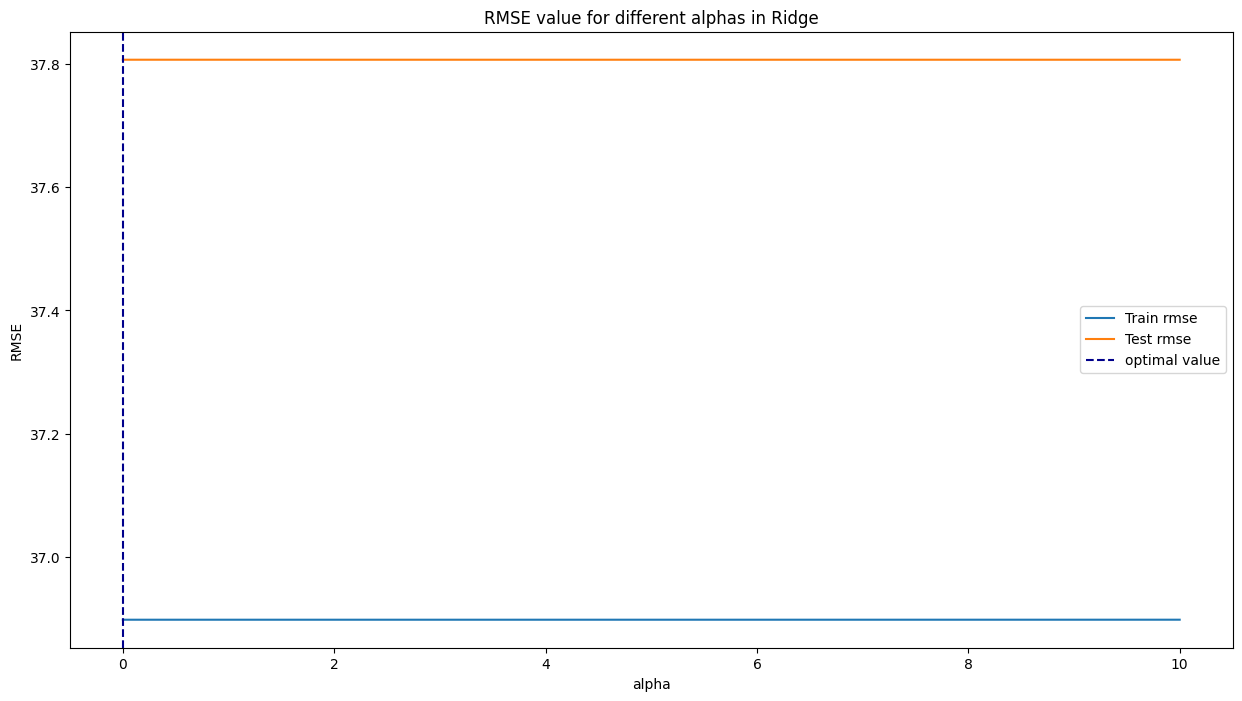

In [ ]:
ridge_alphas = np.linspace(0.0001, 10, num=20)

ridge_train_rmse = []
ridge_test_rmse = []

for alpha in ridge_alphas:
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_train, y_train)

    train_preds = ridge.predict(X_train)
    ridge_train_rmse.append(root_mean_squared_error(y_train, train_preds))

    test_preds = ridge.predict(X_test)
    ridge_test_rmse.append(root_mean_squared_error(y_test, test_preds))


plt.figure(figsize = (15,8))
plt.plot(ridge_alphas, ridge_train_rmse, label='Train rmse')
plt.plot(ridge_alphas, ridge_test_rmse, label='Test rmse')

plt.title("RMSE value for different alphas in Ridge")
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()

# np.argmin() returns the index of the minimum value in a list
optimal_alpha = ridge_alphas[np.argmin(test_rmse)]

# Add a vertical line where the test rmse is minimized
plt.axvline(optimal_alpha, color='darkblue', linestyle='--', label = "optimal value")
plt.legend();


print(f'Optimal Alpha Value for Ridge is: {float(optimal_alpha)}')

print(min(ridge_train_rmse))
print(min(ridge_test_rmse))

Same as linear result.

#Random forest

[33.691779395623776, 33.503565797554224, 33.334181974859334, 32.95326275358448, 32.49557710808451, 32.02104068360006, 31.235055194549567]
[34.69683907789885, 34.54854562916358, 34.4279348032122, 34.36803633553652, 34.317027608527475, 34.34837108516441, 34.427608223086054]


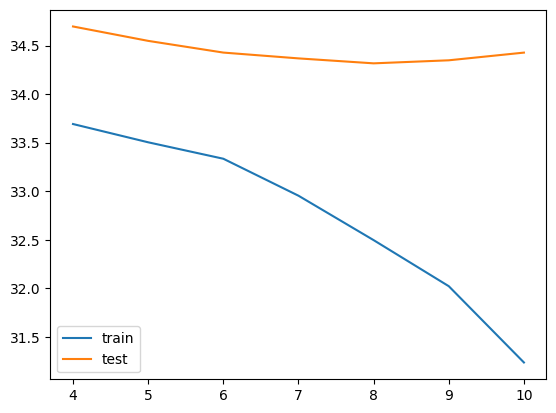

In [ ]:
depths = [4,5,6,7,8,9,10]

test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

Best reult at max depth of 9 with train rmse of 31.9 and test rmse of 34.3404, which is much better than before.

In [ ]:
best_rf = RandomForestRegressor(max_depth=9)
best_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=9)

In [ ]:
feature_importances = best_rf.feature_importances_
feature_names = ct.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 most common factors in the Random Forest Model:")
print(importance_df.head(10))

Top 10 most common factors in the Random Forest Model:
                           Feature  Importance
0   standardize__session_durantion    0.817894
38         encoder__traffic_type_6    0.030054
46             encoder__agent_id_7    0.011409
29     encoder__day_of_week_Monday    0.010873
48             encoder__agent_id_9    0.010749
49            encoder__agent_id_10    0.010465
35         encoder__traffic_type_2    0.009107
9           encoder__hour_of_day_9    0.008271
37         encoder__traffic_type_4    0.007168
27              encoder__locale_L5    0.006511


By far the most common factors in the decision trees in the random forest model is the session duration, with an importance of 0.867.

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgboost = XGBRegressor(max_depth = 9, eval_metric = 'error')
xgboost.fit(X_train, y_train)

train_pred = xgboost.predict(X_train)
test_pred = xgboost.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

26.17043908216248
36.48961362449065


[26.17043908216248, 26.17043908216248, 26.17043908216248, 26.17043908216248, 26.17043908216248, 26.17043908216248, 26.17043908216248]
[36.48961362449065, 36.48961362449065, 36.48961362449065, 36.48961362449065, 36.48961362449065, 36.48961362449065, 36.48961362449065]


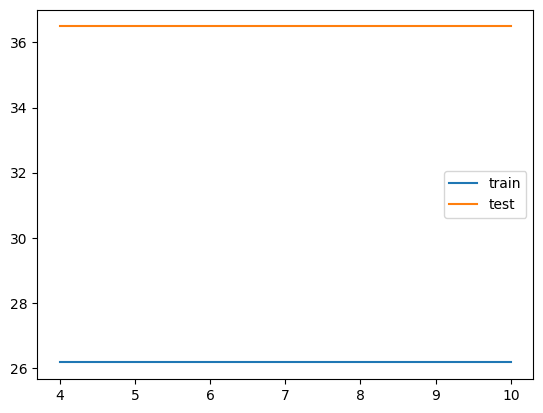

In [ ]:
depths = [4,5,6,7,8,9,10]

test_rmses = []
train_rmses = []
for depth in depths:
  xgboost = XGBRegressor(max_depth = 9, eval_metric = 'error')
  xgboost.fit(X_train, y_train)
  train_pred = xgboost.predict(X_train)
  test_pred = xgboost.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

On test data, performs worse than normal random forest model.

#Pre-process with all columns

In [ ]:
df_processed = df.copy()

# Calculate the number of unique path IDs in each set
df_processed['num_path_ids'] = df_processed['path_id_set'].apply(lambda x: len(set(str(x).split(';'))))

# Extract the first path ID. Handle cases where the string might be empty or invalid after conversion to string.
df_processed['first_path_id'] = df_processed['path_id_set'].apply(lambda x: str(x).split(';')[0] if pd.notna(x) else '')




In [ ]:
df_processed.nunique()

,0
row_num,615668
locale,6
day_of_week,7
hour_of_day,24
agent_id,15
entry_page,136
path_id_set,107045
traffic_type,7
session_durantion,9465
hits,812


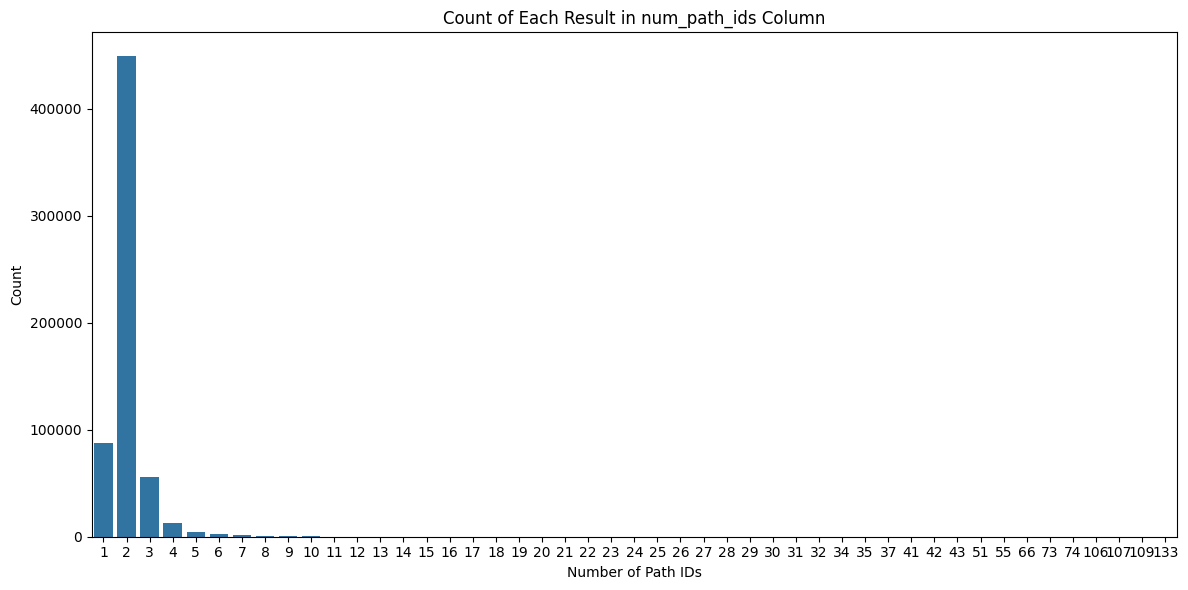

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_processed, x='num_path_ids')
plt.title('Count of Each Result in num_path_ids Column')
plt.xlabel('Number of Path IDs')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

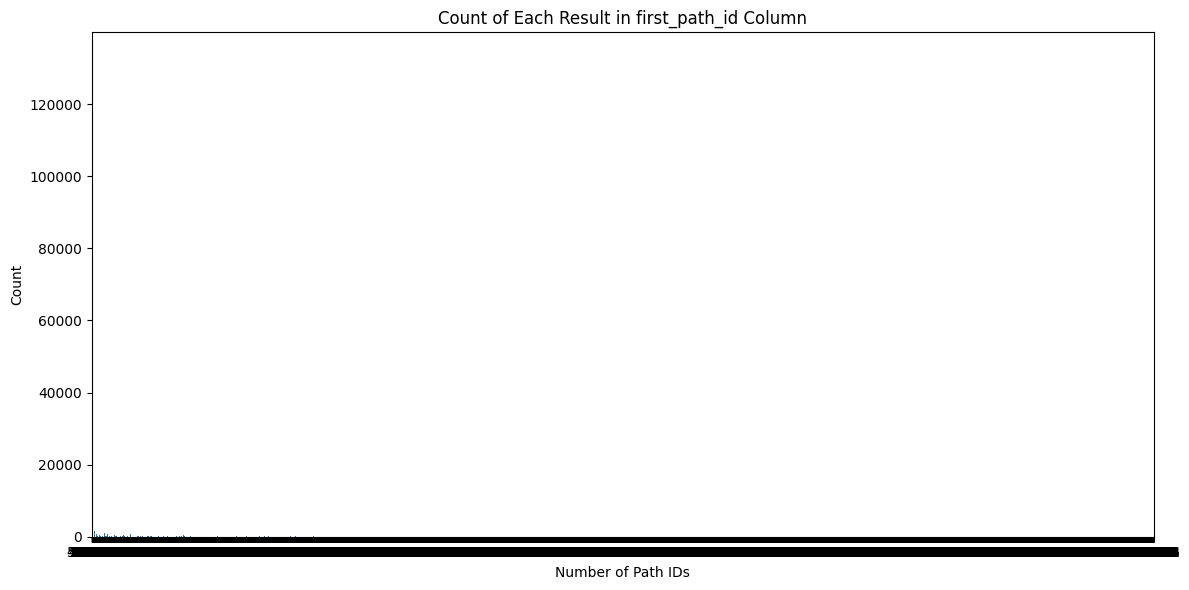

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_processed, x='first_path_id')
plt.title('Count of Each Result in first_path_id Column')
plt.xlabel('Number of Path IDs')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

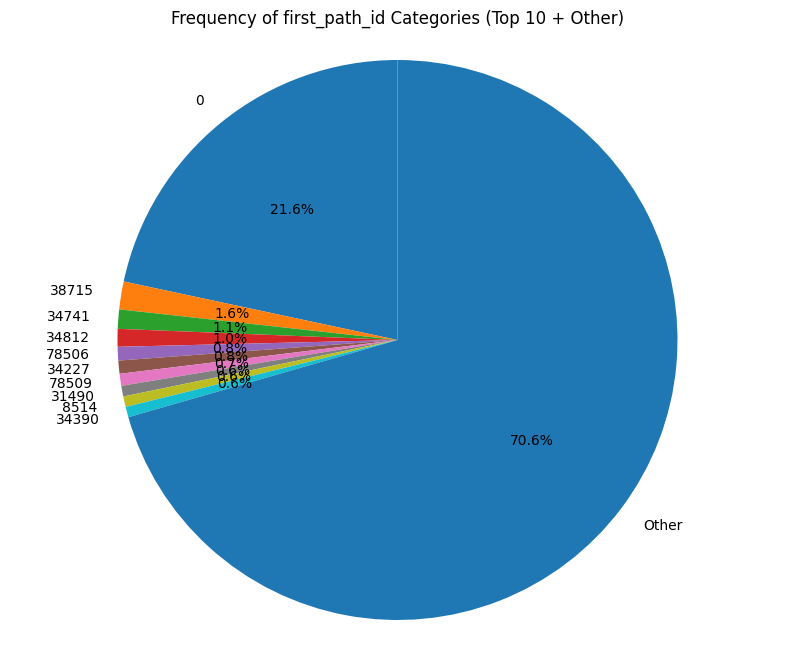

In [ ]:
# Calculate the frequency of each first_path_id
first_path_id_counts = df_processed['first_path_id'].value_counts()

# Select the top N categories (e.g., top 10) and group the rest as 'Other'
num_top_categories = 10
top_categories = first_path_id_counts.head(num_top_categories)
other_count = first_path_id_counts.iloc[num_top_categories:].sum()

# Create a new series for plotting
if other_count > 0:
    plot_data = pd.concat([top_categories, pd.Series({'Other': other_count})])
else:
    plot_data = top_categories

# Create the pie chart
plt.figure(figsize=(10, 8))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title('Frequency of first_path_id Categories (Top 10 + Other)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

70.6% fall into the other categry, rather than the top 10 results.

In [ ]:
print(first_path_id_counts)

first_path_id
0         133279
38715       9899
34741       6828
34812       6297
78506       4838
           ...  
35441          1
37627          1
105431         1
43310          1
51134          1
Name: count, Length: 21878, dtype: int64


In [ ]:
thresholds = [10, 100, 1000, 10000, 50000, 100000, 200000]

print("Number of categories in first_path_id_counts less than each value:")
for threshold in thresholds:
    count_less_than_threshold = (first_path_id_counts < threshold).sum()
    print(f"Less than {threshold:<7}: {count_less_than_threshold} categories")


Number of categories in first_path_id_counts less than each value:
Less than 10     : 16948 categories
Less than 100    : 21097 categories
Less than 1000   : 21821 categories
Less than 10000  : 21877 categories
Less than 50000  : 21877 categories
Less than 100000 : 21877 categories
Less than 200000 : 21878 categories


Of the 21878 unique results for first item in path_id, only 781 have over 100 results. The ones with less than this are probably very prone to overfitting due to small samples so could probably be grouped into an other category.

In [ ]:
# Get the list of first_path_ids that have less than 100 counts
low_count_first_path_ids = set(first_path_id_counts[first_path_id_counts < 100].index)

# Replace these low-count first_path_ids with 'Other' in df_processed using apply
df_processed['first_path_id'] = df_processed['first_path_id'].apply(lambda x: 'Other' if x in low_count_first_path_ids else x)

# Display the updated value counts for verification (optional)
print(df_processed['first_path_id'].value_counts())

first_path_id
Other     163259
0         133279
38715       9899
34741       6828
34812       6297
           ...  
31959        100
71853        100
509604       100
15471        100
35213        100
Name: count, Length: 782, dtype: int64


Then do same for entry page.

In [ ]:
print(df_processed['entry_page'].value_counts())

entry_page
2113    205968
2116    125338
2100    108456
2111     51932
2114     44589
         ...  
2840         1
2711         1
2721         1
2728         1
2503         1
Name: count, Length: 136, dtype: int64


In [ ]:
thresholds = [10, 100, 1000, 10000, 100000]

print("Number of categories in first_path_id_counts less than each value:")
for threshold in thresholds:
    count_less_than_threshold = (df_processed['entry_page'].value_counts() < threshold).sum()
    print(f"Less than {threshold:<7}: {count_less_than_threshold} categories")


Number of categories in first_path_id_counts less than each value:
Less than 10     : 71 categories
Less than 100    : 102 categories
Less than 1000   : 124 categories
Less than 10000  : 128 categories
Less than 100000 : 133 categories


In [ ]:
entry_page_counts = df_processed['entry_page'].value_counts()

# Get the list of entry_page that have less than 100 counts
low_count_entry_page = set(entry_page_counts[entry_page_counts < 100].index)

# Replace these low-count entry_page with 'Other' in df_processed using apply
df_processed['entry_page'] = df_processed['entry_page'].apply(lambda x: 'Other' if x in low_count_entry_page else x)

# Display the updated value counts for verification (optional)
print(df_processed['entry_page'].value_counts())

entry_page
2113     205968
2116     125338
2100     108456
2111      51932
2114      44589
2700      38823
8001      10867
2115      10655
2226       6397
2316       2012
2227       1821
2142       1275
Other      1253
2391        996
2317        652
2704        607
2370        605
2365        455
2166        322
2358        307
2146        284
2306        243
2775        223
2170        187
2371        146
2119        144
2283        144
2257        143
2181        132
2153        124
2155        124
2362        122
2252        116
2145        104
2188        102
Name: count, dtype: int64


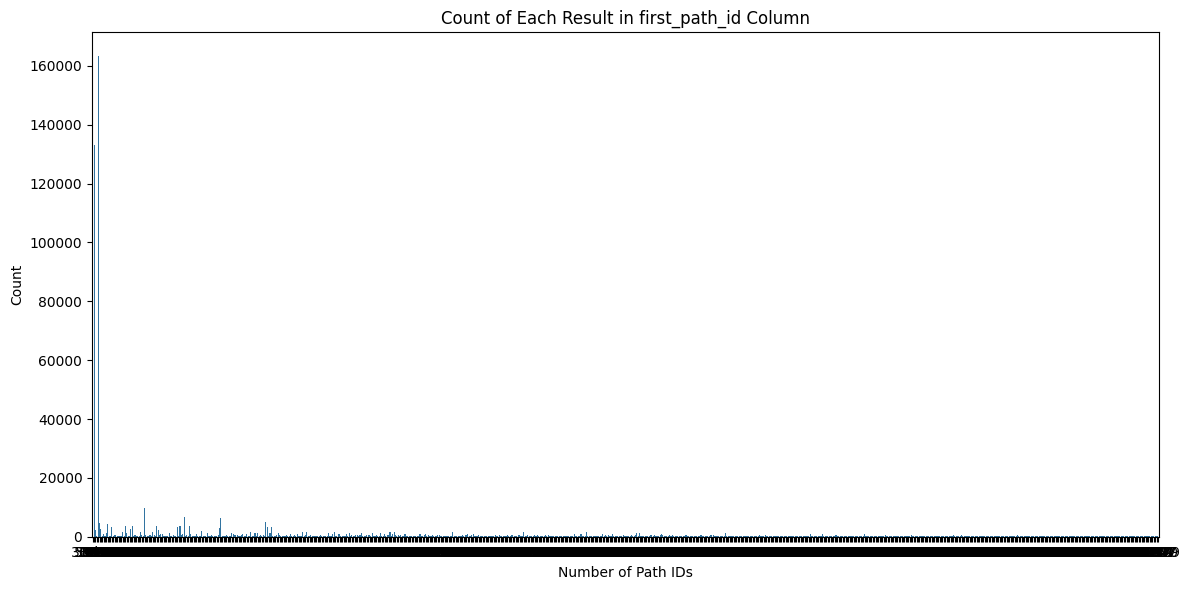

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_processed, x='first_path_id')
plt.title('Count of Each Result in first_path_id Column')
plt.xlabel('Number of Path IDs')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Group all first_path_id with counts less than 100 to other, to reduce cardinality and help prevent overfitting from small categories.

In [ ]:
# Re-define X and y, including the new features and excluding the original 'path_id_set'
X = df_processed.drop(columns = ["row_num", "hits", "path_id_set"])
y = df_processed["hits"]

# Split data again with new X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

print(X_train.shape)


(430967, 9)


In [ ]:
X_train.head()

,locale,day_of_week,hour_of_day,agent_id,entry_page,traffic_type,session_durantion,num_path_ids,first_path_id
924338,L2,Monday,8,8,2113,2,2715.0,2,8514
264018,L3,Wednesday,17,9,2100,1,98.0,2,34554
909992,L5,Sunday,9,8,2113,6,5.0,2,46814
321658,L4,Tuesday,0,10,2113,2,195.0,2,78514
329463,L4,Wednesday,21,9,2111,2,196.0,3,Other


In [ ]:
# Update numerical and categorical columns for ColumnTransformer
numerical_cols = ["session_durantion", "num_path_ids", "hour_of_day"]

categorical_cols = ["locale", "day_of_week", "traffic_type", "agent_id"]

large_cat_cols = ['first_path_id', 'entry_page']

With high cardinality for first term in path_id, one hot encoding would create too many categories. Tried target encoding, but took about an hour for each with random forest, and often stopped while running, so using other encoding methods.

In [ ]:
# Re-create and fit the ColumnTransformer
from category_encoders import BinaryEncoder

ohe = OneHotEncoder(drop = "first",  sparse_output= False)
sd = StandardScaler()
be = BinaryEncoder() # Instantiate BinaryEncoder

ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ,("binary_encoder", be, large_cat_cols)
      ], remainder = "passthrough")

ct.set_output(transform="pandas")

X_train = ct.fit_transform(X_train, y_train) # Pass y_train for TargetEncoder
X_test = ct.transform(X_test)

print("Shape of X_train after feature engineering and transformation:", X_train.shape)
print("Shape of X_test after feature engineering and transformation:", X_test.shape)

Shape of X_train after feature engineering and transformation: (430967, 50)
Shape of X_test after feature engineering and transformation: (184701, 50)


In [ ]:
X_train.head()

,standardize__session_durantion,standardize__num_path_ids,standardize__hour_of_day,encoder__locale_L2,encoder__locale_L3,encoder__locale_L4,encoder__locale_L5,encoder__locale_L6,encoder__day_of_week_Monday,encoder__day_of_week_Saturday,...,binary_encoder__first_path_id_6,binary_encoder__first_path_id_7,binary_encoder__first_path_id_8,binary_encoder__first_path_id_9,binary_encoder__entry_page_0,binary_encoder__entry_page_1,binary_encoder__entry_page_2,binary_encoder__entry_page_3,binary_encoder__entry_page_4,binary_encoder__entry_page_5
924338,1.180287,-0.076257,-0.768463,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,1,0,0,0,0,0,1
264018,-0.209973,-0.076257,0.562196,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,1,0,0,0,0,0,1,0
909992,-0.259378,-0.076257,-0.620612,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,1,1,0,0,0,0,0,1
321658,-0.158442,-0.076257,-1.951270,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,1
329463,-0.157911,0.946914,1.153599,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,1,0,1,0,0,0,0,1,1


#Linear

In [ ]:
lm = LinearRegression()

lm.fit(X_train, y_train)

print(lm.score(X_train, y_train))


# model rmse
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

0.23609841280385924
34.05518040767023
34.77459422846921


Has train rmse of 34.0 and test rmse of 34.7, which is an improvement on linear from before, but not as good as previous random forest.

#Random forest

[28.337567242489353, 27.326751925428777, 26.290067067865696, 25.369138390260666, 24.165808872902822, 23.195741943126322]
[32.32154046750622, 32.319803609586856, 32.337458250270906, 32.31136859892047, 32.368849351362705, 32.40594481296755]


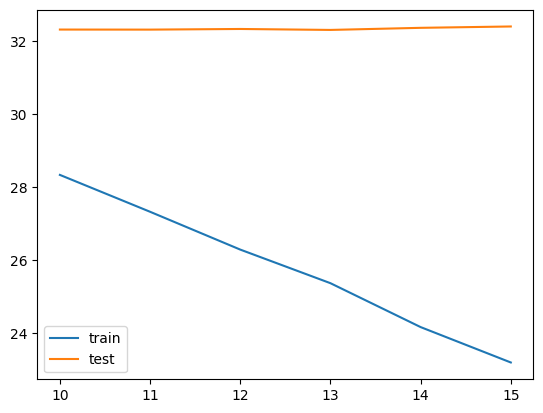

In [ ]:
depths = [10,11,12,13,14,15]

test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth, n_jobs=-1)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

With binary encoder, best random forest had test rmse of 32.31, at a max depth of 13, which is an improvement on before.

Try wth different target encoder

In [ ]:
# Re-define X and y, including the new features and excluding the original 'path_id_set'
X = df_processed.drop(columns = ["row_num", "hits", "path_id_set"])
y = df_processed["hits"]

# Split data again with new X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

print(X_train.shape)

(430967, 9)


In [ ]:
from category_encoders import TargetEncoder

ohe = OneHotEncoder(drop = "first",  sparse_output= False)
sd = StandardScaler()
te = TargetEncoder() # Instantiate TargetEncoder

ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ,("target_encoder", te, large_cat_cols)
      ], remainder = "passthrough")

ct.set_output(transform="pandas")

X_train = ct.fit_transform(X_train, y_train) # Pass y_train for TargetEncoder
X_test = ct.transform(X_test)

print("Shape of X_train after feature engineering and transformation:", X_train.shape)
print("Shape of X_test after feature engineering and transformation:", X_test.shape)

Shape of X_train after feature engineering and transformation: (430967, 36)
Shape of X_test after feature engineering and transformation: (184701, 36)


In [ ]:
depths = [6,7,8,9,10,11,12,13,14]

test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth, n_jobs=-1)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
  print(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

32.780015650868144
32.56087878401157
32.39071107864564
32.25351783226187
32.301574029774265
32.29518040547136
32.3282314686928


The test rmse is lowest at a max depth of 12, with a rmse of 32.38. This is slightly worse than the binary encoder.

Try with smaller limit to allow first_path_id of 10

In [ ]:
# Get the list of first_path_ids that have less than 100 counts
low_count_first_path_ids = set(first_path_id_counts[first_path_id_counts < 10].index)

# Replace these low-count first_path_ids with 'Other' in df_processed using apply
df_processed['first_path_id'] = df_processed['first_path_id'].apply(lambda x: 'Other' if x in low_count_first_path_ids else x)

# Re-define X and y, including the new features and excluding the original 'path_id_set'
X = df_processed.drop(columns = ["row_num", "hits", "path_id_set"])
y = df_processed["hits"]

# Split data again with new X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

print(X_train.shape)

# Update numerical and categorical columns for ColumnTransformer
numerical_cols = ["session_durantion", "num_path_ids", "hour_of_day"]

categorical_cols = ["locale", "day_of_week", "traffic_type", "agent_id"]

large_cat_cols = ['first_path_id', 'entry_page']

In [ ]:
ohe = OneHotEncoder(drop = "first",  sparse_output= False)
sd = StandardScaler()
be = BinaryEncoder() # Instantiate BinaryEncoder

ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ,("binary_encoder", be, large_cat_cols)
      ], remainder = "passthrough")

ct.set_output(transform="pandas")

X_train = ct.fit_transform(X_train, y_train) # Pass y_train for TargetEncoder
X_test = ct.transform(X_test)

print("Shape of X_train after feature engineering and transformation:", X_train.shape)
print("Shape of X_test after feature engineering and transformation:", X_test.shape)

#Linear

In [ ]:
lm = LinearRegression()

lm.fit(X_train, y_train)

print(lm.score(X_train, y_train))


# model rmse
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

Slightly better than previous linear test rmse.

#Random forest

In [ ]:
depths = [5,6,7,8,9,10,11,12,13,14,15]

test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth, n_jobs=-1)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.legend(["train", "test"])
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Random Forest Model Performance')
print(train_rmses)
print(test_rmses)

Best result of test rmse was 32.29 with max depth of 13, which is a slight improvement.

In [ ]:
best_rf = RandomForestRegressor(max_depth=11, n_jobs=-1)
best_rf.fit(X_train, y_train)

feature_importances = best_rf.feature_importances_
feature_names = ct.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 most common factors in the Random Forest Model:")
print(importance_df.head(10))

In [ ]:
explainer_depth1 = shap.TreeExplainer(best_rf)


In [ ]:
shap_values_depth1 = explainer_depth1(X_test)

In [ ]:
shap.plots.bar(shap_values_depth1)

In [ ]:
shap.plots.beeswarm(shap_values_depth1)

#Target encoding

In [ ]:
# Update numerical and categorical columns for ColumnTransformer
numerical_cols = ["session_durantion", "num_path_ids", "hour_of_day"]

categorical_cols = ["locale", "day_of_week", "traffic_type", "agent_id"]

large_cat_cols = ['first_path_id', 'entry_page']

X = df_processed.drop(columns = ["row_num", "hits", "path_id_set"])
y = df_processed["hits"]

# Split data again with new X
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state = 2)

print(X_train.shape)

ohe = OneHotEncoder(drop = "first",  sparse_output= False)
sd = StandardScaler()
te = TargetEncoder() # Instantiate TargetEncoder

ct = ColumnTransformer(transformers = [
      ("standardize", sd, numerical_cols)
      ,("encoder", ohe, categorical_cols)
      ,("target_encoder", te, large_cat_cols)
      ], remainder = "passthrough")

ct.set_output(transform="pandas")

X_train = ct.fit_transform(X_train, y_train) # Pass y_train for TargetEncoder
X_test = ct.transform(X_test)

print("Shape of X_train after feature engineering and transformation:", X_train.shape)
print("Shape of X_test after feature engineering and transformation:", X_test.shape)

In [ ]:
lm = LinearRegression()

lm.fit(X_train, y_train)

print(lm.score(X_train, y_train))


# model rmse
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print(train_rmse)
print(test_rmse)

In [ ]:
depths = [5,6,7,8,9,10,11,12,13,14,15]

test_rmses = []
train_rmses = []
for depth in depths:
  rf = RandomForestRegressor(max_depth=depth, n_jobs=-1)
  rf.fit(X_train, y_train)
  train_pred = rf.predict(X_train)
  test_pred = rf.predict(X_test)
  train_rmses.append(root_mean_squared_error(y_train, train_pred))
  test_rmses.append(root_mean_squared_error(y_test, test_pred))
plt.plot(depths, train_rmses)
plt.plot(depths, test_rmses)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Random Forest Model Performance')
plt.legend(["train", "test"])
print(train_rmses)
print(test_rmses)

Best result at max depth of 11 with a rmse of 32.30.

In [ ]:
best_rf = RandomForestRegressor(max_depth=11, n_jobs=-1)
best_rf.fit(X_train, y_train)

feature_importances = best_rf.feature_importances_
feature_names = ct.get_feature_names_out()

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Top 10 most common factors in the Random Forest Model:")
print(importance_df.head(10))

In [ ]:
explainer_depth1 = shap.TreeExplainer(best_rf)

In [ ]:
shap_values_depth1 = explainer_depth1(X_test)

In [ ]:
shap.plots.bar(shap_values_depth1)

In [ ]:
shap.plots.beeswarm(shap_values_depth1)

To do:
-repeat machine learning with length and start of num_path_ids

-maybe add future places??

-identify most important features

-identify how these features impact the number of hits